#### Wikipedia Retriever

- A **Wikipedia Retriever** is a retriever that queries the Wikipedia API to fetch relevant content for a given query.
---
##### How It Works

1. You give it a query (e.g., `"Albert Einstein"`)
2. It sends the query to Wikipedia's API
3. It retrieves the most relevant articles
4. It returns them as LangChain `Document` objects


In [1]:
from langchain_community.retrievers import WikipediaRetriever 

In [2]:
# Initialize the retriever (optional: set language and top_k)
retriever = WikipediaRetriever(top_k_results=2, lang="en")

In [3]:

# Define your query
query = "the geopolitical history of india and pakistan from the perspective of a chinese"

# Get relevant Wikipedia documents
docs = retriever.invoke(query)

In [4]:
docs

[Document(metadata={'title': 'Dominion of Pakistan', 'summary': 'The Dominion of Pakistan, officially Pakistan, was the Pakistani state between 1947 and 1956, when it existed as an independent federal dominion in the British Commonwealth of Nations. It was established on 14 August 1947 when it became independent from British India under the Indian Independence Act 1947 of the British parliament, which also established an independent Dominion of India on 15 August. The dominion ceased to exist on 23 March 1956, when the Constituent Assembly of Pakistan adopted a constitution which established Pakistan as a republic.\nThe new dominion consisted of those presidencies and provinces of British India which were allocated to it in the Partition of India. Until 1947, these regions had been ruled by the United Kingdom as a part of the British Empire.\nIts status as a federal dominion ended in 1956 with the completion of the constitution of Pakistan, which established the country as a republic. 

In [5]:
# Print retrieved content
for i, doc in enumerate(docs):
    print(f"\n--- Result {i+1} ---")
    print(f"Content:\n{doc.page_content}...")  # truncate for display


--- Result 1 ---
Content:
The Dominion of Pakistan, officially Pakistan, was the Pakistani state between 1947 and 1956, when it existed as an independent federal dominion in the British Commonwealth of Nations. It was established on 14 August 1947 when it became independent from British India under the Indian Independence Act 1947 of the British parliament, which also established an independent Dominion of India on 15 August. The dominion ceased to exist on 23 March 1956, when the Constituent Assembly of Pakistan adopted a constitution which established Pakistan as a republic.
The new dominion consisted of those presidencies and provinces of British India which were allocated to it in the Partition of India. Until 1947, these regions had been ruled by the United Kingdom as a part of the British Empire.
Its status as a federal dominion ended in 1956 with the completion of the constitution of Pakistan, which established the country as a republic. The constitution also administratively s

#### Vector Store Retriever

- A **Vector Store Retriever** in LangChain is the most common type of retriever that lets you search and fetch documents from a vector store based on **semantic similarity** using **vector embeddings**.
---
##### How It Works

1. You store your documents in a vector store  
   (e.g., FAISS, Chroma, Weaviate)

2. Each document is converted into a **dense vector** using an embedding model

3. When the user enters a query:
   - The query is also converted into a vector.
   - The retriever compares the query vector with the stored vectors.
   - It retrieves the **top-k most similar documents** and returns them as LangChain `Document` objects.

In [6]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document 

In [7]:
# Step 1: Your source documents
documents = [
    Document(page_content="LangChain helps developers build LLM applications easily."),
    Document(page_content="Chroma is a vector database optimized for LLM-based search."),
    Document(page_content="Embeddings convert text into high-dimensional vectors."),
    Document(page_content="OpenAI provides powerful embedding models."),
]

In [8]:
# Step 2: Initialize embedding model
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

# Step 3: Create Chroma vector store in memory
## here enbeddding getting created for each document and stored in chroma vector db.
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    collection_name="my_collection",
    persist_directory='my_chroma_retrievers' 
)

In [9]:
# Step 4: Convert vectorstore into a retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 2}) 

In [10]:
query = "What is Chroma used for?" 
results = retriever.invoke(query)

In [11]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Chroma is a vector database optimized for LLM-based search.

--- Result 2 ---
Chroma is a vector database optimized for LLM-based search.


In [12]:
query = "What is Chroma used for?"
results = vectorstore.similarity_search(query, k=2)
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Chroma is a vector database optimized for LLM-based search.

--- Result 2 ---
Chroma is a vector database optimized for LLM-based search.


---
##### Why is a Retriever required when a Vector Store can perform similarity search?
- Although a **vector store** can directly perform similarity search, a **retriever** is required because it provides a **standardized, flexible, and extensible abstraction layer** that integrates seamlessly with LangChain pipelines.
---
##### Role of a Vector Store (Storage Layer)
- A vector store is responsible for:
    - Storing document embeddings  
    - Performing low-level similarity search  
    - Returning documents using distance metrics (cosine, L2, etc.)
</Br> 
- It is mainly a **storage + search engine**, not a runnable component.
---
##### Why LangChain Introduces a Retriever </Br>
1. Separation of Concerns

    - Vector Store → data storage + raw search  
    - Retriever → retrieval logic  <br>

- This separation makes systems easier to maintain and extend.</Br>

2. Pluggability and Flexibility
- Using a retriever allows switching between:
    - Similarity search  
    - MMR (Maximum Marginal Relevance)  
    - Metadata filtering  
    - Hybrid retrieval (BM25 + vectors)  
- without changing downstream code.</br> 
3. Standard Interface for Chains
LangChain components like:
- RetrievalQA  
- ConversationalRetrievalChain  
- RAG pipelines  
expect a **retriever**, not a raw vector store.
---
##### Important Difference (Key Point)
- **Vector Store** → NOT runnable, cannot be chained directly  
- **Retriever** → Runnable (`invoke()`), so it can be composed into complex chains and agents
---
### RDBMS Analogy (Intuition)
| RDBMS | LangChain |
|-----|----------|
| Database table | Vector store |
| SQL query | Retriever logic |
| ORM | Retriever abstraction |

- Even though we can query a table directly, real systems use an abstraction layer.
---
##### Why Both Sometimes Give the Same Result
In simple cases:
```python
vector_store.similarity_search(q)
retriever.invoke(q)

In [ ]:
results = vectorstore.similarity_search(query, k=2)

In [ ]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)

#### MMR (Maximum Marginal Relevance (MMR) Retriever)

> **Question:**  
> *How can we pick results that are not only relevant to the query but also different from each other?*

---

##### What is MMR?

**MMR (Maximum Marginal Relevance)** is an information retrieval algorithm designed to **reduce redundancy** in retrieved results while **maintaining high relevance** to the query.

---

##### Why MMR Retriever?

In regular similarity search, you may get documents that are:
- All very similar to each other
- Repeating the same information
- Lacking diverse perspectives

---

##### How MMR Avoids This

MMR works by:
1. Picking the **most relevant document** first
2. Then picking the next document that is:
   - Still relevant to the query
   - **Least similar** to already selected documents
3. Repeating this process until `k` documents are selected

---

##### Why This Matters in RAG Pipelines

MMR is especially useful when:
- You want your **context window** to contain **diverse but relevant information**
- Documents are **semantically overlapping**
- You want better **coverage**, not repetition


In [13]:
# Sample documents
docs = [
    Document(page_content="LangChain makes it easy to work with LLMs."),
    Document(page_content="LangChain is used to build LLM based applications."),
    Document(page_content="Chroma is used to store and search document embeddings."),
    Document(page_content="Embeddings are vector representations of text."),
    Document(page_content="MMR helps you get diverse results when doing similarity search."),
    Document(page_content="LangChain supports Chroma, FAISS, Pinecone, and more."),
]

In [14]:
from langchain_community.vectorstores import FAISS

# Initialize OpenAI embeddings
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

# Step 2: Create the FAISS vector store from documents
vectorstore = FAISS.from_documents(
    documents=docs,
    embedding=embedding_model
)

 - MMR = λ × relevance − (1 − λ) × redundancy

 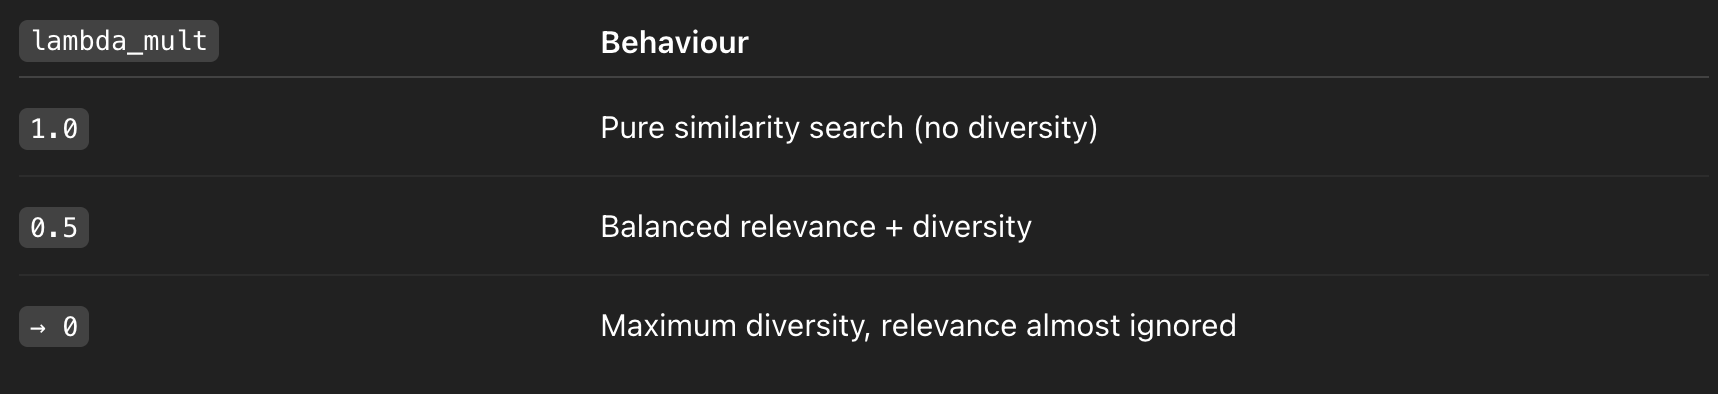

In [15]:
# Enable MMR (Maximum Marginal Relevance) in the retriever
# MMR working as vanilla Similariy search
retriever = vectorstore.as_retriever(
    search_type="mmr",  # Enables MMR: balances relevance and diversity
    search_kwargs={
        "k": 3,
        "lambda_mult": 1  # 1.0 → pure similarity search,
                            # 0.0 → maximum diversity (relevance minimized)
    }
)



In [16]:
query = "What is langchain?"
results = retriever.invoke(query)

In [17]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
LangChain is used to build LLM based applications.

--- Result 2 ---
LangChain makes it easy to work with LLMs.

--- Result 3 ---
LangChain supports Chroma, FAISS, Pinecone, and more.


In [18]:
# Enable MMR (Maximum Marginal Relevance) in the retriever
retriever = vectorstore.as_retriever(
    search_type="mmr",  # Enables MMR: balances relevance and diversity
    search_kwargs={
        "k": 3,
        "lambda_mult":0.5   # 1.0 → pure similarity search,
                            # 0.0 → maximum diversity (relevance minimized)
    }
)

query = "What is langchain?"
results = retriever.invoke(query)

for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
LangChain is used to build LLM based applications.

--- Result 2 ---
Embeddings are vector representations of text.

--- Result 3 ---
LangChain supports Chroma, FAISS, Pinecone, and more.


##### Multiquery Retriever

In [19]:
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI
# from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain_classic.retrievers import MultiQueryRetriever

In [20]:
# Relevant health & wellness documents
all_docs = [
    Document(page_content="Regular walking boosts heart health and can reduce symptoms of depression.", metadata={"source": "H1"}),
    Document(page_content="Consuming leafy greens and fruits helps detox the body and improve longevity.", metadata={"source": "H2"}),
    Document(page_content="Deep sleep is crucial for cellular repair and emotional regulation.", metadata={"source": "H3"}),
    Document(page_content="Mindfulness and controlled breathing lower cortisol and improve mental clarity.", metadata={"source": "H4"}),
    Document(page_content="Drinking sufficient water throughout the day helps maintain metabolism and energy.", metadata={"source": "H5"}),
    Document(page_content="The solar energy system in modern homes helps balance electricity demand.", metadata={"source": "I1"}),
    Document(page_content="Python balances readability with power, making it a popular system design language.", metadata={"source": "I2"}),
    Document(page_content="Photosynthesis enables plants to produce energy by converting sunlight.", metadata={"source": "I3"}),
    Document(page_content="The 2022 FIFA World Cup was held in Qatar and drew global energy and excitement.", metadata={"source": "I4"}),
    Document(page_content="Black holes bend spacetime and store immense gravitational energy.", metadata={"source": "I5"}),
]

In [21]:
# Initialize OpenAI embeddings
embedding_model = OpenAIEmbeddings()

# Create FAISS vector store
vectorstore = FAISS.from_documents(documents=all_docs, embedding=embedding_model)

In [22]:
# Create retrievers
similarity_retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 5})

In [23]:
multiquery_retriever = MultiQueryRetriever.from_llm(
    retriever=vectorstore.as_retriever(search_kwargs={"k": 5}),
    llm=ChatOpenAI(model="gpt-3.5-turbo")
)

In [24]:
# Query
query = "How to improve energy levels and maintain balance?"

In [25]:
# Retrieve results
similarity_results = similarity_retriever.invoke(query)
multiquery_results= multiquery_retriever.invoke(query)

In [26]:
for i, doc in enumerate(similarity_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)

print("*"*150)

for i, doc in enumerate(multiquery_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Drinking sufficient water throughout the day helps maintain metabolism and energy.

--- Result 2 ---
Mindfulness and controlled breathing lower cortisol and improve mental clarity.

--- Result 3 ---
Regular walking boosts heart health and can reduce symptoms of depression.

--- Result 4 ---
Deep sleep is crucial for cellular repair and emotional regulation.

--- Result 5 ---
The solar energy system in modern homes helps balance electricity demand.
******************************************************************************************************************************************************

--- Result 1 ---
Drinking sufficient water throughout the day helps maintain metabolism and energy.

--- Result 2 ---
Deep sleep is crucial for cellular repair and emotional regulation.

--- Result 3 ---
The solar energy system in modern homes helps balance electricity demand.

--- Result 4 ---
Mindfulness and controlled breathing lower cortisol and improve mental clarity.

-

In [17]:
# ===============================
# Imports (LangChain 1.x)
# ===============================
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI

# ===============================
# Step 1: Toy documents
# ===============================
all_docs = [
    Document(page_content="Regular walking boosts heart health and can reduce symptoms of depression.", metadata={"source": "H1"}),
    Document(page_content="Consuming leafy greens and fruits helps detox the body and improve longevity.", metadata={"source": "H2"}),
    Document(page_content="Deep sleep is crucial for cellular repair and emotional regulation.", metadata={"source": "H3"}),
    Document(page_content="Mindfulness and controlled breathing lower cortisol and improve mental clarity.", metadata={"source": "H4"}),
    Document(page_content="Drinking sufficient water throughout the day helps maintain metabolism and energy.", metadata={"source": "H5"}),
    Document(page_content="The solar energy system in modern homes helps balance electricity demand.", metadata={"source": "I1"}),
    Document(page_content="Python balances readability with power, making it a popular system design language.", metadata={"source": "I2"}),
    Document(page_content="Photosynthesis enables plants to produce energy by converting sunlight.", metadata={"source": "I3"}),
    Document(page_content="The 2022 FIFA World Cup was held in Qatar and drew global energy and excitement.", metadata={"source": "I4"}),
    Document(page_content="Black holes bend spacetime and store immense gravitational energy.", metadata={"source": "I5"}),
]

# ===============================
# Step 2: Build FAISS vector store
# ===============================
vectorstore = FAISS.from_documents(
    all_docs,
    OpenAIEmbeddings(model="text-embedding-3-small")
)

similarity_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


# ===============================
# Step 3: Baseline similarity search
# ===============================
query = "How to improve energy levels and maintain balance?"

similarity_results = similarity_retriever.invoke(query)


# ===============================
# Step 4: Multi-Query logic (LangChain 1.x style)
# ===============================
llm = ChatOpenAI(model="gpt-5-nano",temperature=0)

def generate_queries(question: str, n: int = 3):
    prompt = f"""
Generate {n} different ways to ask the following question.
Return each query on a new line.

Question: {question}
"""
    response = llm.invoke(prompt)
    # print(response)
    return [q.strip() for q in response.text.split("\n") if q.strip()]


def multiquery_retrieve(retriever, question: str):
    queries = generate_queries(question)

    all_results = []
    for q in queries:
        docs = retriever.invoke(q)
        all_results.extend(docs)

    # Deduplicate using page content
    # dictionary comprehension to remove duplicates based on page_content,
    # key=actual content of document, value=Langchain Document 
    unique_docs = {
        doc.page_content: doc for doc in all_results
    }

    return list(unique_docs.values())


multiquery_results = multiquery_retrieve(similarity_retriever, query)


# ===============================
# Step 5: Display results
# ===============================
print("\n================ SIMILARITY SEARCH RESULTS ================\n")
for i, doc in enumerate(similarity_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)

print("\n" + "*" * 150 + "\n")

print("================ MULTI-QUERY SEARCH RESULTS ================\n")
for i, doc in enumerate(multiquery_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content) 



================ SIMILARITY SEARCH RESULTS ================


--- Result 1 ---
Drinking sufficient water throughout the day helps maintain metabolism and energy.

--- Result 2 ---
Consuming leafy greens and fruits helps detox the body and improve longevity.

--- Result 3 ---
Mindfulness and controlled breathing lower cortisol and improve mental clarity.

******************************************************************************************************************************************************

================ MULTI-QUERY SEARCH RESULTS ================


--- Result 1 ---
Drinking sufficient water throughout the day helps maintain metabolism and energy.

--- Result 2 ---
Regular walking boosts heart health and can reduce symptoms of depression.

--- Result 3 ---
Consuming leafy greens and fruits helps detox the body and improve longevity.


##### ContextualCompressionRetriever

In [31]:
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import LLMChainExtractor
from langchain_core.documents import Document
# from langchain.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers import ContextualCompressionRetriever

In [28]:
# Recreate the document objects from the previous data
docs = [
    Document(page_content=(
        """The Grand Canyon is one of the most visited natural wonders in the world.
        Photosynthesis is the process by which green plants convert sunlight into energy.
        Millions of tourists travel to see it every year. The rocks date back millions of years."""
    ), metadata={"source": "Doc1"}),

    Document(page_content=(
        """In medieval Europe, castles were built primarily for defense.
        The chlorophyll in plant cells captures sunlight during photosynthesis.
        Knights wore armor made of metal. Siege weapons were often used to breach castle walls."""
    ), metadata={"source": "Doc2"}),

    Document(page_content=(
        """Basketball was invented by Dr. James Naismith in the late 19th century.
        It was originally played with a soccer ball and peach baskets. NBA is now a global league."""
    ), metadata={"source": "Doc3"}),

    Document(page_content=(
        """The history of cinema began in the late 1800s. Silent films were the earliest form.
        Thomas Edison was among the pioneers. Photosynthesis does not occur in animal cells.
        Modern filmmaking involves complex CGI and sound design."""
    ), metadata={"source": "Doc4"})
]

In [29]:
# Create a FAISS vector store from the documents
embedding_model = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(docs, embedding_model)

In [32]:
base_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

In [33]:
# Set up the compressor using an LLM
llm = ChatOpenAI(model="gpt-3.5-turbo")
compressor = LLMChainExtractor.from_llm(llm)

In [34]:
# Create the contextual compression retriever
compression_retriever = ContextualCompressionRetriever(
    base_retriever=base_retriever,
    base_compressor=compressor
)

In [35]:
# Query the retriever
query = "What is photosynthesis?"
compressed_results = compression_retriever.invoke(query)

In [36]:
for i, doc in enumerate(compressed_results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)



--- Result 1 ---
Photosynthesis is the process by which green plants convert sunlight into energy.

--- Result 2 ---
The chlorophyll in plant cells captures sunlight during photosynthesis.


In [18]:
## Step-1: Create sample documents
from langchain_core.documents import Document

docs = [
    Document(page_content="""
Walking daily improves cardiovascular health.
It also helps maintain energy levels.
Unrelated note: Penguins live in Antarctica.
""", metadata={"source": "D1"}),

    Document(page_content="""
Deep sleep supports brain function and cellular repair.
Sleep deprivation reduces energy and focus.
Fun fact: The moon affects ocean tides.
""", metadata={"source": "D2"}),

    Document(page_content="""
Solar panels convert sunlight into electrical energy.
This is renewable energy technology.
Cats sleep 12–16 hours a day.
""", metadata={"source": "D3"})
]


In [19]:
## Step-2: Build a FAISS retriever (normal retrieval)
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

vectorstore = FAISS.from_documents(
    docs,
    OpenAIEmbeddings()
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


In [20]:
## Step-3: What happens WITHOUT compression
query = "How to improve energy levels?"
retrieved_docs = retriever.invoke(query)
print("=== Retrieved (Uncompressed) ===")
for d in retrieved_docs:
    print(d.page_content)

=== Retrieved (Uncompressed) ===

Walking daily improves cardiovascular health.
It also helps maintain energy levels.
Unrelated note: Penguins live in Antarctica.


Deep sleep supports brain function and cellular repair.
Sleep deprivation reduces energy and focus.
Fun fact: The moon affects ocean tides.


Solar panels convert sunlight into electrical energy.
This is renewable energy technology.
Cats sleep 12–16 hours a day.



In [21]:
## Step-4:from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5-nano",temperature=0)

def compress_document(doc: Document, query: str) -> Document:
    prompt = f"""
Given the question:
"{query}"

Extract ONLY the sentences from the text below that are relevant.
If nothing is relevant, return an empty string.

Text:
{doc.page_content}
"""
    response = llm.invoke(prompt)

    return Document(
        page_content=response.content.strip(),
        metadata=doc.metadata
    )


In [22]:
## Step-5: Apply compression to retrieved docs
def contextual_compression_retrieve(retriever, query: str):
    retrieved_docs = retriever.invoke(query)

    compressed_docs = []
    for doc in retrieved_docs:
        compressed = compress_document(doc, query)
        if compressed.page_content:  # keep only useful docs
            compressed_docs.append(compressed)

    return compressed_docs


In [23]:
## Step-6:Run Contextual Compression
compressed_results = contextual_compression_retrieve(
    retriever,
    "How to improve energy levels?"
)

print("\n=== Retrieved + Compressed ===")
for d in compressed_results:
    print(d.page_content)



=== Retrieved + Compressed ===
Walking daily improves cardiovascular health.
It also helps maintain energy levels.
Deep sleep supports brain function and cellular repair.
Sleep deprivation reduces energy and focus.
Cats sleep 12–16 hours a day.
